<h1>Train — ConvNeXt-Tiny</h1>

Trains and evaluates ConvNeXt-Tiny using the tuned hyperparameters from `ARCH_HYPERPARAMS["convnext_tiny"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): CapeFlats
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 785 | Val: 192 | Test: 766


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["convnext_tiny"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ConvNeXt-Tiny: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ConvNeXt-Tiny: micro batch = 8, accumulation steps = 1 (effective batch size ≈ 8, tuned value = 8)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ConvNeXt-Tiny)
# ---------------------------------------------------------
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

model.avgpool = nn.AdaptiveMaxPool2d(1)

in_f = model.classifier[2].in_features
model.classifier[2] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
# criterion = FocalLoss(weight=class_weights_arch, gamma=2.0)  # parked for later -- see todo.txt

optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)

scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ConvNeXt-Tiny] Epoch   1/100 | LR: 6.78e-05 | train loss 0.9286 acc 0.638 | val loss 0.6819 acc 0.755 *


[ConvNeXt-Tiny] Epoch   2/100 | LR: 6.78e-05 | train loss 0.7342 acc 0.698 | val loss 0.6000 acc 0.698 *


[ConvNeXt-Tiny] Epoch   3/100 | LR: 6.78e-05 | train loss 0.6747 acc 0.741 | val loss 0.3884 acc 0.807 *


[ConvNeXt-Tiny] Epoch   4/100 | LR: 6.78e-05 | train loss 0.5615 acc 0.795 | val loss 0.4898 acc 0.792


[ConvNeXt-Tiny] Epoch   5/100 | LR: 6.78e-05 | train loss 0.4765 acc 0.819 | val loss 0.5450 acc 0.729


...

[ConvNeXt-Tiny] Epoch  20/100 | LR: 6.78e-05 | train loss 0.1290 acc 0.958 | val loss 0.3492 acc 0.885


[ConvNeXt-Tiny] Epoch  21/100 | LR: 6.78e-05 | train loss 0.0977 acc 0.964 | val loss 0.4076 acc 0.885


[ConvNeXt-Tiny] Epoch  22/100 | LR: 6.78e-05 | train loss 0.1575 acc 0.953 | val loss 0.3475 acc 0.880


[ConvNeXt-Tiny] Epoch  23/100 | LR: 6.78e-05 | train loss 0.1004 acc 0.962 | val loss 0.5542 acc 0.875


[ConvNeXt-Tiny] Epoch  24/100 | LR: 6.78e-05 | train loss 0.1189 acc 0.962 | val loss 0.3584 acc 0.880

[ConvNeXt-Tiny] No val loss improvement for 10 epochs — stopping early at epoch 24.

[ConvNeXt-Tiny] Restored best checkpoint (val loss = 0.2800)


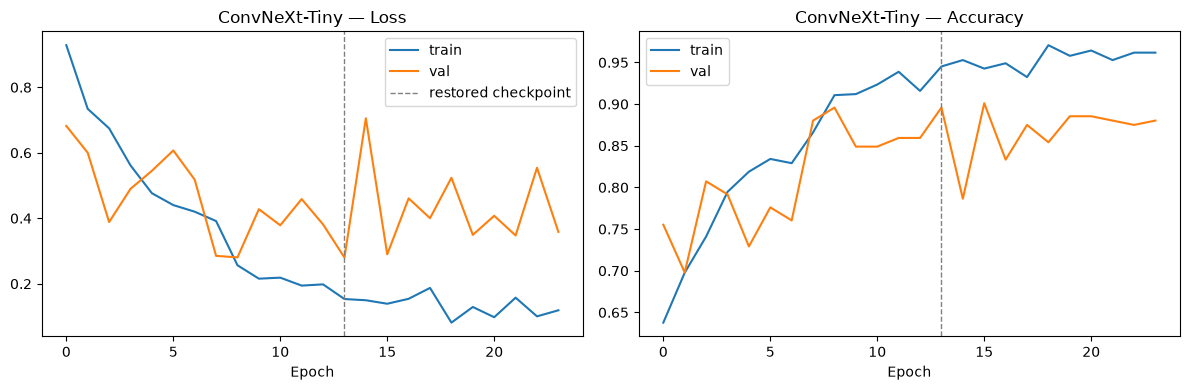

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ConvNeXt-Tiny", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ConvNeXt-Tiny")

## Evaluate on the test set

[ConvNeXt-Tiny] Test accuracy: 0.411


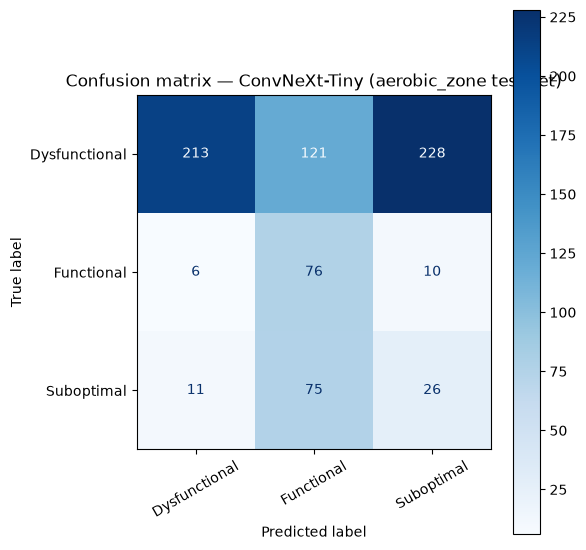

               precision    recall  f1-score   support

Dysfunctional      0.926     0.379     0.538       562
   Functional      0.279     0.826     0.418        92
   Suboptimal      0.098     0.232     0.138       112

     accuracy                          0.411       766
    macro avg      0.435     0.479     0.365       766
 weighted avg      0.727     0.411     0.465       766



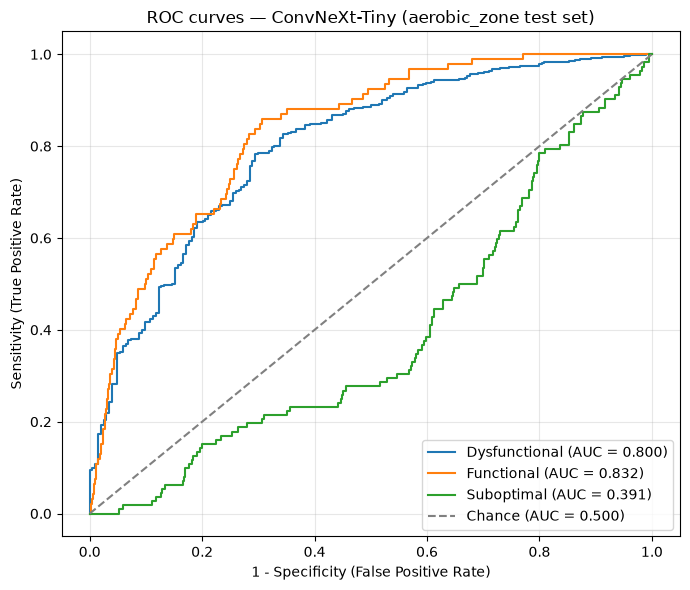

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.800
  Functional     : 0.832
  Suboptimal     : 0.391

Mean AUC (over 3/3 classes with test examples): 0.674


(np.float64(0.4112271540469974),
 {'Dysfunctional': 0.8000750122112903,
  'Functional': 0.8315056121790736,
  'Suboptimal': 0.39075469637396243})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ConvNeXt-Tiny", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ConvNeXt-Tiny", "convnext_tiny")

Saved results to ../results/aerobic_zone_aug/results_aerobic_zone_convnext_tiny_CapeFlats.pkl
Saved model weights to ../models/aerobic_zone_convnext_tiny_cnn.pt
